# Import Modules

In [36]:
import warnings
warnings.filterwarnings("ignore")

import os
import glob
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


In [45]:
def extract_hybrid_features(file_path, max_pad_len=128):
    # Load audio
    y, sr = librosa.load(file_path, duration=3, offset=0.5)

    # If it's too short, librosa.feature.delta will crash
    if len(y) < sr * 0.4: 
        return None
            
    # Normalize audio
    y = librosa.util.normalize(y)

    # 1. MFCC - 20
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    # Delta MFCC - 20
    mfcc_delta = librosa.feature.delta(mfcc)

    # Delta-Delta MFCC - 20
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    # 2. Chroma - 12
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)

    # 3. RMS Energy - 1
    rms = librosa.feature.rms(y=y)

    # 4. Spectral Features - 3
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)

    # 5. Zero Crossing Rate - 1
    zcr = librosa.feature.zero_crossing_rate(y)

    # Combine All Features - 77
    combined = np.vstack([
        mfcc,
        mfcc_delta,
        mfcc_delta2,
        chroma,
        rms,
        centroid,
        bandwidth,
        rolloff,
        zcr
    ])
    # Padding / Truncation
    if combined.shape[1] < max_pad_len:
        pad_width = max_pad_len - combined.shape[1]
        combined = np.pad(combined, ((0,0),(0,pad_width)), mode='constant')
    else:
        combined = combined[:, :max_pad_len]

    return combined.T

def makeThePlot(Y):
    df = pd.DataFrame({'emotion': Y})
    
    # 1. Set the visual style
    plt.figure(figsize=(10, 5))
    sns.set_style("whitegrid")
    
    # 2. Create the distribution chart
    ax = sns.countplot(x='emotion', data=df, palette='viridis', order=df['emotion'].value_counts().index)
    
    # 3. Add titles and labels
    plt.title('Distribution of Emotions in Dataset', fontsize=15)
    plt.xlabel('Emotion Category', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(rotation=45) # Rotates labels for better readability
    
    # 4. Show the plot
    plt.show()

# 1. CREMA-D

Extracting hybrid features from 7442 CREMA-D files...


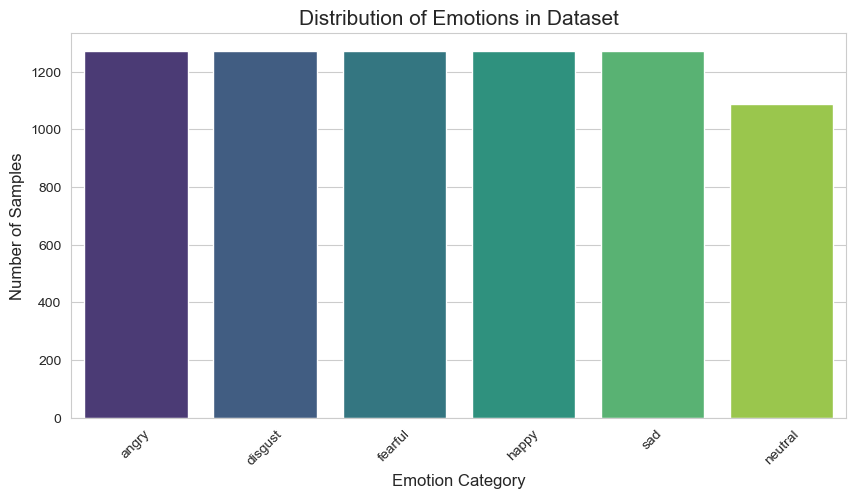

In [4]:
# CREMA-D emotion mapping
CREMAD_MAP = {'ANG':'angry', 'DIS':'disgust', 'FEA':'fearful', 'HAP':'happy', 
              'NEU':'neutral', 'SAD':'sad'}
Y_cremad = []
def load_cremad_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} CREMA-D files...")

    for file in file_list:
        # Filename example: 1001_DFA_ANG_XX.wav
        # Split by '_' and take the 3rd element (index 2)
        code = os.path.basename(file).split('_')[2]
        emotion = CREMAD_MAP.get(code)
        if emotion:
            # X.append(extract_hybrid_features(file))
            # y.append(emotion)
            Y_cremad.append(emotion)
            
    return np.array(X), np.array(y)

CREMAD_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\CREMA-D\AudioWAV"
X_cremad, y_cremad = load_cremad_data(CREMAD_PATH)


# 6 emotions : angry, fearful, disgust, sad, happy, neutral
makeThePlot(Y_cremad)

# 2. EMOD-DB

Extracting hybrid features from 535 EMO-DB files...


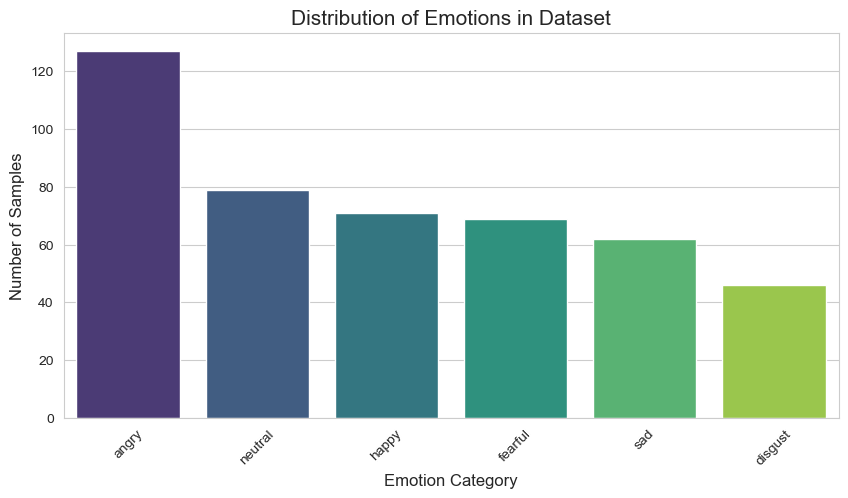

In [28]:
# EMO-DB emotion mapping
# W:Wut (angry), L:Langeweile (boredom), E:Ekel (disgust), A:Angst (fearful), 
# F:Freude (happy), T:Trauer (sad), N:Neutral (neutral)
EMODB_MAP = {'W':'angry', 'L':'boredom', 'E':'disgust', 'A':'fearful', 
             'F':'happy', 'T':'sad', 'N':'neutral'}

Y_emodb = []
def load_emodb_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} EMO-DB files...")

    for file in file_list:
        fname = os.path.basename(file)
        # The 6th character (index 5) represents the emotion
        code = fname[5]
        emotion = EMODB_MAP.get(code)
        if emotion == 'boredom': # skipping the feature with least counts
            continue
        if emotion:
            # X.append(extract_hybrid_features(file))
            # y.append(emotion)
            Y_emodb.append(emotion)
            
    return np.array(X), np.array(y)

EMODB_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\EMO-DB\wav"
X_emodb, y_emodb = load_emodb_data(EMODB_PATH)


# 7 emotions : angry, boredom, disgust, fearful, happy, sad, neutral
makeThePlot(Y_emodb)

# 3. ESD

Extracting hybrid features from 35000 ESD files...


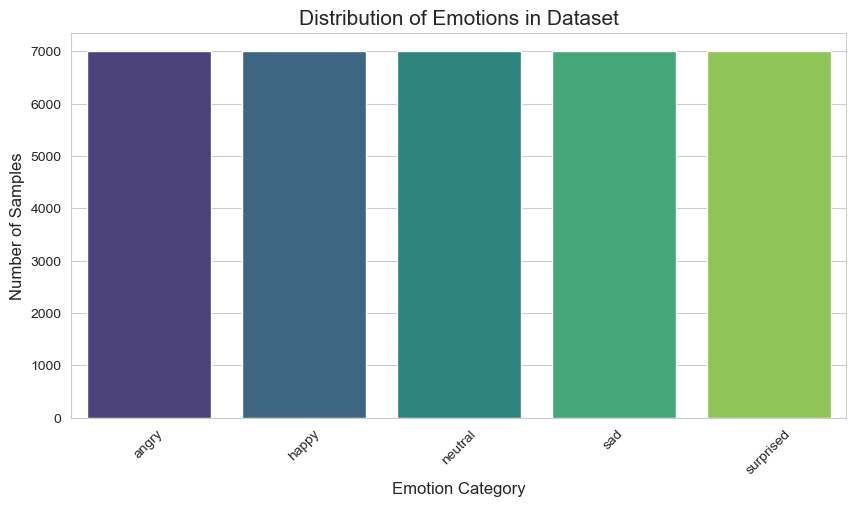

In [8]:
# ESD emotion mapping
# ESD has folders: 'Angry', 'Happy', 'Neutral', 'Sad', 'Surprise'
ESD_MAP = {
    'angry': 'angry', 
    'happy': 'happy', 
    'neutral': 'neutral', 
    'sad': 'sad', 
    'surprise': 'surprised'
}

Y_esd = []
def load_esd_data(data_path):
    X, y = [], []
    # This glob pattern goes into: Speaker Folders (0001) -> Emotion Folders (Angry) -> .wav
    file_list = glob.glob(os.path.join(data_path, "*", "*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} ESD files...")

    for file in file_list:
        folder_name = os.path.basename(os.path.dirname(file)).lower()
        emotion = ESD_MAP.get(folder_name)
        if emotion:
            # X.append(extract_hybrid_features(file))
            # y.append(emotion)
            Y_esd.append(emotion)
            
    return np.array(X), np.array(y)

ESD_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\ESD\Emotion Speech Dataset"
X_esd, y_esd = load_esd_data(ESD_PATH)


# 5 emotions : angry, surprised, happy, sad, neutral

makeThePlot(Y_esd)

# 4. HINDI

Extracting hybrid features from 3200 HINDI files...


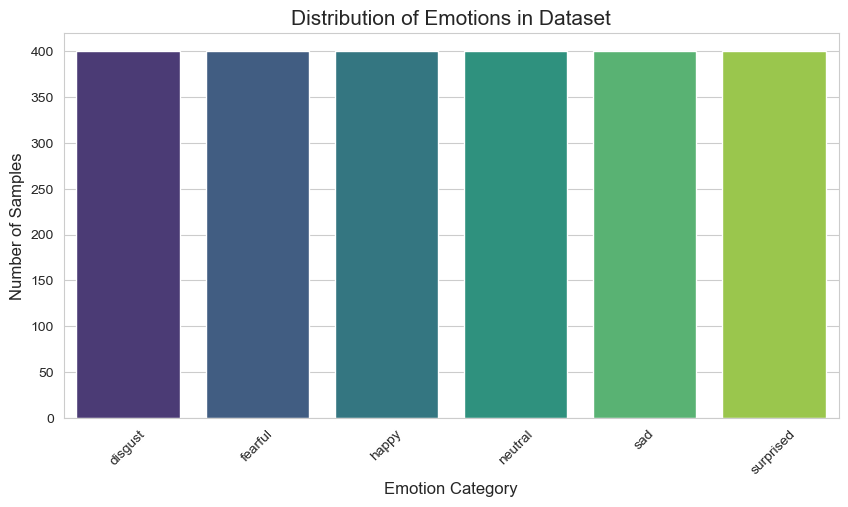

In [29]:
# Mapping to your standard labels
HINDI_MAP = {
    'neutral': 'neutral',
    'happy': 'happy',
    'sad': 'sad',
    'angry': 'angry',
    'fear': 'fearful',
    'disgust': 'disgust',
    'surprise': 'surprised',
    'sarcastic': 'sarcastic'
}

Y_hindi = []
def load_hindi_data(data_path):
    X, y = [], []
    # This pattern goes into: Speaker (6) -> Session (session1) -> Emotion (neutral) -> *.wav
    file_list = glob.glob(os.path.join(data_path, "*", "*", "*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} HINDI files...")

    for file in file_list:
        folder_name = os.path.basename(os.path.dirname(file)).lower()
        emotion = HINDI_MAP.get(folder_name)
        if emotion == 'sarcastic': # skipping the feature with least counts
            continue
        if emotion:
            # X.append(extract_hybrid_features(file))
            # y.append(emotion)
            Y_hindi.append(emotion)
            
    return np.array(X), np.array(y)

HINDI_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\HINDI\my Dataset"
X_hindi, y_hindi = load_hindi_data(HINDI_PATH)


# 8 emotions : angry, surprised, sarcastic, disgust, fearful, happy, sad, neutral

makeThePlot(Y_hindi)

# 5. JL Corpus

Extracting hybrid features from 2400 JL Corpus files...


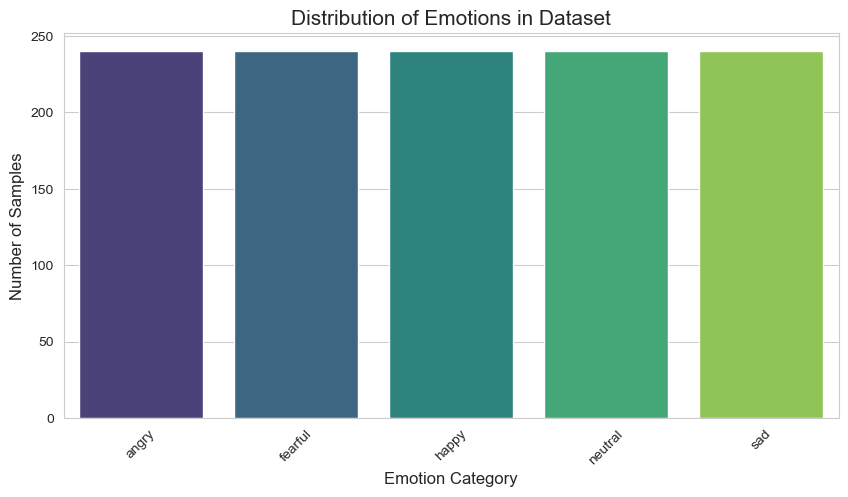

In [30]:
# JL Corpus specific mapping
JL_MAP = {
    'angry': 'angry',
    'anxious': 'fearful',
    'apologetic': 'apologetic',
    'assertive': 'assertive',
    'concerned': 'concerned',
    'encouraging': 'encouraging',
    'excited': 'excited',
    'happy': 'happy',
    'neutral': 'neutral',
    'sad': 'sad'
}

Y_jl = []
def load_jl_corpus_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} JL Corpus files...")

    for file in file_list:
        fname = os.path.basename(file)
        # female1_angry_2a_1.wav -> parts[1] is 'angry'
        parts = fname.split('_')
        
        if len(parts) > 1:
            code = parts[1].lower()
            emotion = JL_MAP.get(code)
            if emotion in ['apologetic', 'assertive', 'concerned', 'encouraging', 'excited']: # skipping the feature with least counts
                continue
            if emotion:
                # X.append(extract_hybrid_features(file))
                # y.append(emotion)
                Y_jl.append(emotion)
            
    return np.array(X), np.array(y)

JL_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\JL Corpus\Raw JL corpus (unchecked and unannotated)\JL(wav+txt)"
X_jl, y_jl = load_jl_corpus_data(JL_PATH)


# 10 emotions : angry, anxious, apologetic, assertive, concerned, encouraging, excited, happy, neutral, sad

makeThePlot(Y_jl)

# 6. MELD

In [17]:
# !conda install -c conda-forge ffmpeg --solver=classic -y
# Not installed

In [46]:
# import os
import imageio_ffmpeg
import subprocess

# 1. Get the exact path to the binary
ffmpeg_path = imageio_ffmpeg.get_ffmpeg_exe()
ffmpeg_dir = os.path.dirname(ffmpeg_path)

# 2. Add the directory to the PATH so audioread can find it
os.environ["PATH"] += os.pathsep + ffmpeg_dir

# 3. Create a 'fake' ffmpeg.exe by copying/renaming if it doesn't exist
fake_ffmpeg = os.path.join(ffmpeg_dir, "ffmpeg.exe")
if not os.path.exists(fake_ffmpeg):
    import shutil
    shutil.copy(ffmpeg_path, fake_ffmpeg)

# 4. Verify it works in the terminal
try:
    res = subprocess.run(["ffmpeg", "-version"], capture_output=True, text=True)
    print("Success! ffmpeg is now recognized as a system command.")
except Exception as e:
    print(f" Still not working: {e}")


Success! ffmpeg is now recognized as a system command.


In [47]:
# Mapping MELD emotions
MELD_MAP = {
    'neutral': 'neutral',
    'surprise': 'surprised',
    'fear': 'fearful',
    'sadness': 'sad',
    'joy': 'happy',
    'anger': 'angry',
    'disgust': 'disgust'
}

Y_meld = []
def load_meld_data(csv_path, video_dir):
    X, y = [], []
    count_neutral = 0
    count_happy = 0
    MAXN = 1200
    # 1. Load the CSV
    df = pd.read_csv(csv_path)
    print(f"Processing MELD: {len(df)} entries found in CSV.")
    
    for index, row in tqdm(df.iterrows(), total=len(df)):
        # 2. Construct filename: dia[ID]_utt[ID].mp4
        dia_id = int(row['Dialogue_ID'])
        utt_id = int(row['Utterance_ID'])
        file_name = f"dia{dia_id}_utt{utt_id}.mp4"
        full_path = os.path.join(video_dir, file_name)

        if os.path.exists(full_path):
            # 3. Get emotion from 'Emotion' column
            raw_emotion = str(row['Emotion']).lower()
            emotion = MELD_MAP.get(raw_emotion)
            
            if emotion == 'neutral':
                count_neutral += 1
                if count_neutral > MAXN:
                    continue
            if emotion == 'happy':
                count_happy += 1
                if count_happy > MAXN:
                    continue
            # librosa.load will extract the audio from the .mp4 automatically
            features = extract_hybrid_features(full_path)
            if features is not None:
                X.append(features)
                y.append(emotion)
                Y_meld.append(emotion)
        else:
            continue # Skip if file is missing (common in MELD)

    return np.array(X), np.array(y)

MELD_CSV = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\MELD\MELD-RAW\MELD.Raw\train\train_sent_emo.csv"
MELD_VIDEO_DIR = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\MELD\MELD-RAW\MELD.Raw\train\train_splits"

X_meld, y_meld = load_meld_data(MELD_CSV, MELD_VIDEO_DIR)


# 7 emotions : neutral, surpriced, fearful, sad, happy, angry, disgust

makeThePlot(Y_meld)

Processing MELD: 9989 entries found in CSV.


 12%|█████████████▎                                                                                                    | 1165/9989 [03:44<28:18,  5.19it/s]


NoBackendError: 

# 7. MLEnd

Loaded CSV with 32654 rows.


Processing MLEnd: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 32654/32654 [00:08<00:00, 3675.41it/s]


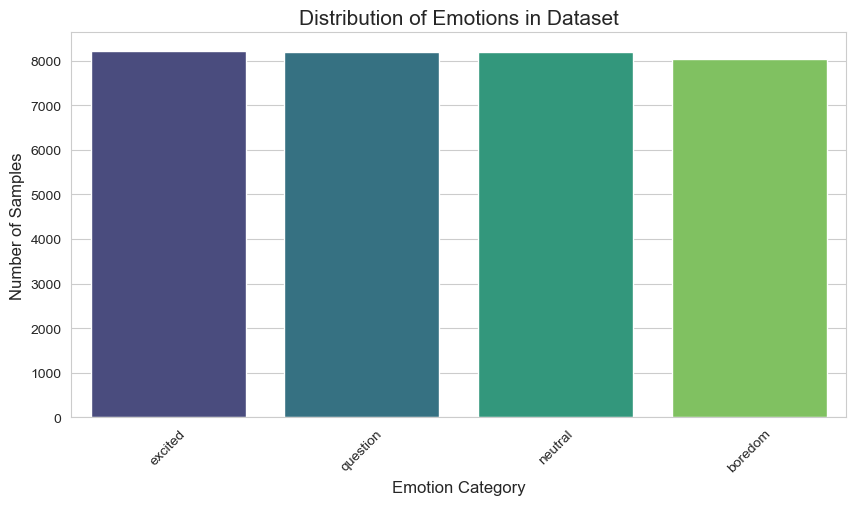

In [15]:
# MLEnd emotion mapping
MLEND_MAP = {
    'excited': 'excited',
    'neutral': 'neutral',
    'bored': 'boredom',
    'question': 'question'
}

Y_mlend = []
def load_mlend_data(csv_path, wav_dir):
    X, y = [], []

    # 1. Load the CSV
    df = pd.read_csv(csv_path)
    print(f"Loaded CSV with {len(df)} rows.")

    # 2. Iterate through the rows
    for index, row in tqdm(df.iterrows(), total=len(df), desc="Processing MLEnd"):
        # The 'Public filer' column contains the ID (e.g., 8)
        # We need to format it to match the filename '00008.wav' (5 digits)
        file_id = str(int(row['Public filename'])).zfill(5)
        file_name = f"{file_id}.wav"
        full_path = os.path.join(wav_dir, file_name)

        if os.path.exists(full_path):
            # The 'Intonation' column contains the emotion
            raw_emotion = str(row['Intonation']).strip().lower()
            emotion = MLEND_MAP.get(raw_emotion)
            Y_mlend.append(emotion)
            # if emotion:
                # features = extract_hybrid_features(full_path)
                # if features is not None:
                    # X.append(features)
                    # y.append(emotion)
        else:
             # print(f"File not found: {full_path}")
             continue
            
    return np.array(X), np.array(y)

# The CSV is in the parent folder, and the wavs are in the subfolder
MLEND_CSV = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\MLEnd\MLEndSND_Audio_Attributes.csv" 
MLEND_WAV_DIR = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\MLEnd\MLEndSND_Public\MLEndSND_Public"

X_mlend, y_mlend = load_mlend_data(MLEND_CSV, MLEND_WAV_DIR)


# 4 emotions : excited, neutral, boredom, question

makeThePlot(Y_mlend)

# 8. RAVDESS

Extracting hybrid features from 1440 RAVDESS files...


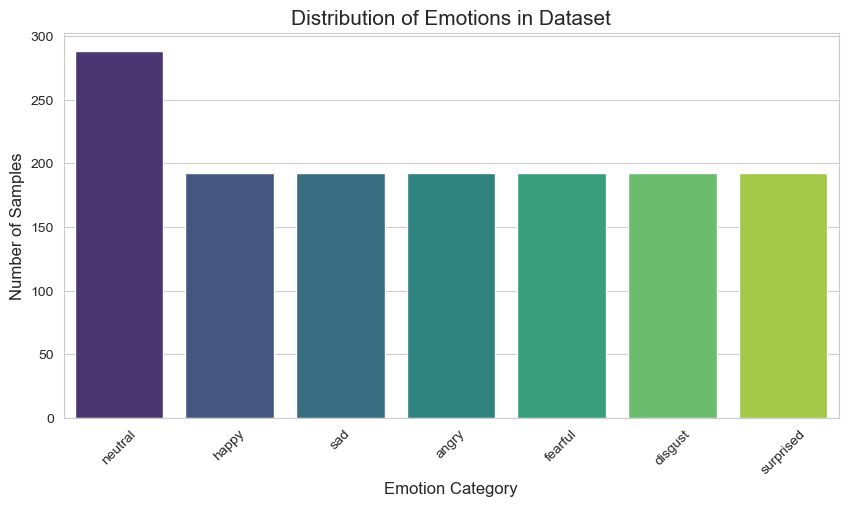

In [32]:
# Full RAVDESS emotion mapping
RAVDESS_MAP = {'01':'neutral', '02':'neutral', '03':'happy', '04':'sad', 
               '05':'angry', '06':'fearful', '07':'disgust', '08':'surprised'}

Y_ravdess = []
def load_ravdess_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "Actor_*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} RAVDESS files...")

    for file in file_list:
        emotion = RAVDESS_MAP[os.path.basename(file).split('-')[2]]
        # X.append(extract_hybrid_features(file))
        # y.append(emotion)
        Y_ravdess.append(emotion)
            
    return np.array(X), np.array(y)
    
DATA_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\RAVDESS"
X_ravdess, y_ravdess = load_ravdess_data(DATA_PATH)


# 8 emotions : neutral, calm, happy, sad, angry, fearful, disgust, surprised

makeThePlot(Y_ravdess)

# 9. SAVEE

Extracting hybrid features from 480 SAVEE files...


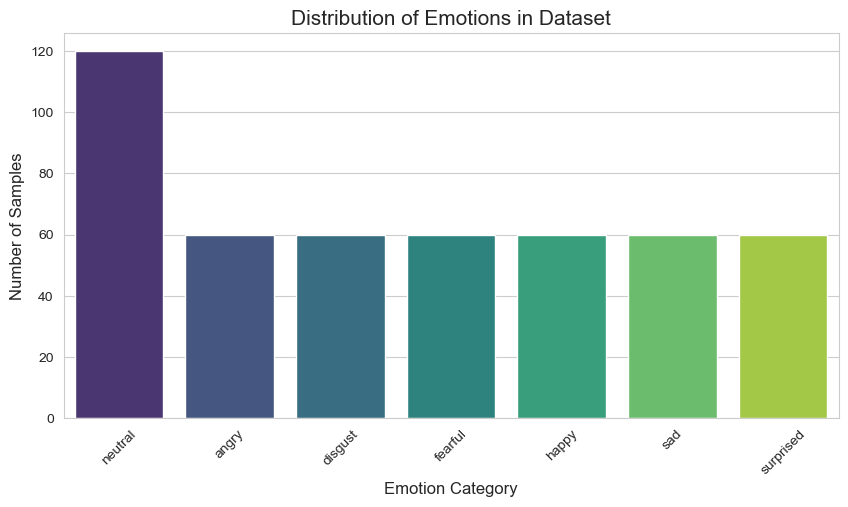

In [21]:
# SAVEE emotion mapping
SAVEE_MAP = {
    'a': 'angry', 
    'd': 'disgust', 
    'f': 'fearful', 
    'h': 'happy', 
    'n': 'neutral', 
    'sa': 'sad', 
    'su': 'surprised'
}

Y_savee = []

def load_savee_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} SAVEE files...")

    for file in file_list:
        fname = os.path.basename(file)
        
        # 1. Split by underscore: 'JE_n15.wav' -> ['JE', 'n15.wav']
        # 2. Take the second part, remove '.wav', and then remove digits
        try:
            parts = fname.split('_')[1].split('.')[0] # results in 'n15' or 'sa02'
            code = "".join([i for i in parts if not i.isdigit()]) # results in 'n' or 'sa'
            emotion = SAVEE_MAP.get(code)
            Y_savee.append(emotion)
            # if emotion:
                # features = extract_hybrid_features(file)
                # if features is not None:
                #     X.append(features)
                #     y.append(emotion)
        except IndexError:
            continue # Skip files that don't follow the 'Speaker_EmotionXX.wav' format
            
    return np.array(X), np.array(y)

SAVEE_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\SAVEE\ALL"
X_savee, y_savee = load_savee_data(SAVEE_PATH)


# 7 emotions : angry, fearful, disgust, sad, happy, surprised, neutral

makeThePlot(Y_savee)

# 10. TESS

Extracting hybrid features from 2800 TESS files...


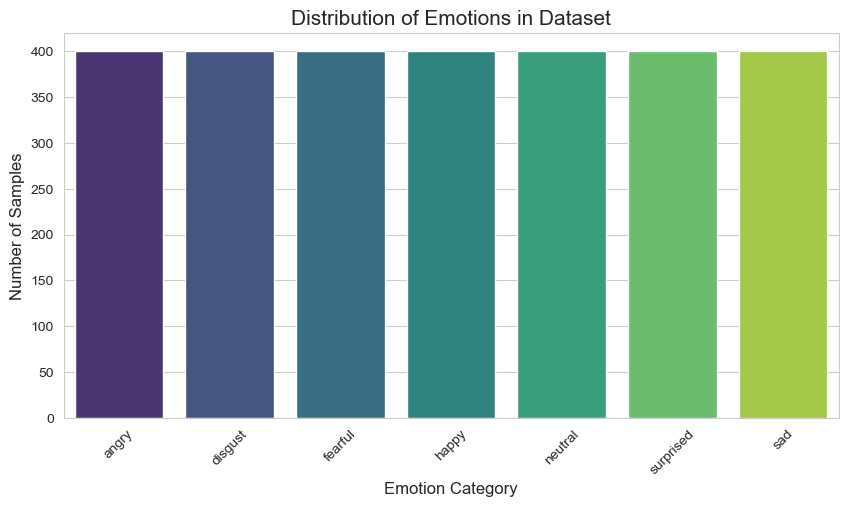

In [22]:
Y_tess = []
def load_tess_data(data_path):
    X, y = [], []
    file_list = glob.glob(os.path.join(data_path, "*", "*.wav"))
    print(f"Extracting hybrid features from {len(file_list)} TESS files...")

    for file in file_list:
        # Get filename (e.g., 'OAF_back_angry.wav')
        fname = os.path.basename(file)
        emotion = fname.split('_')[-1].split('.')[0].lower()
        if emotion == 'ps':
            emotion = 'surprised'
        if emotion == 'fear':
            emotion = 'fearful'
        # X.append(extract_hybrid_features(file))
        # y.append(emotion)
        Y_tess.append(emotion)
            
    return np.array(X), np.array(y)

TESS_PATH = r"F:\Speech_Emotion_Recognition_Mixed_Dataset\TESS\TESS Toronto emotional speech set data"
X_tess, y_tess = load_tess_data(TESS_PATH)


# 7 emotions : angry, fearful, disgust, sad, happy, surprised, neutral

makeThePlot(Y_tess)

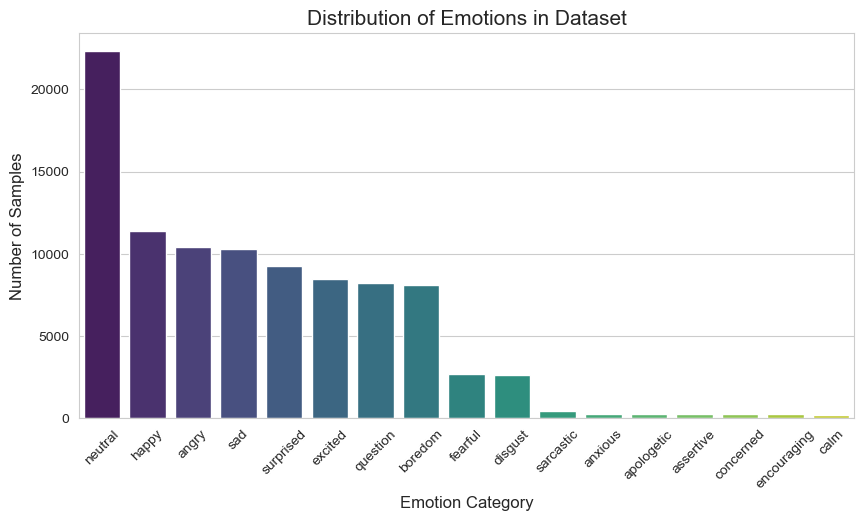

In [25]:
Y_all = np.concatenate([Y_ravdess, Y_tess, Y_savee, Y_cremad, Y_emodb, Y_esd, Y_hindi, Y_jl, Y_mlend, Y_meld], axis=0)
makeThePlot(Y_all)

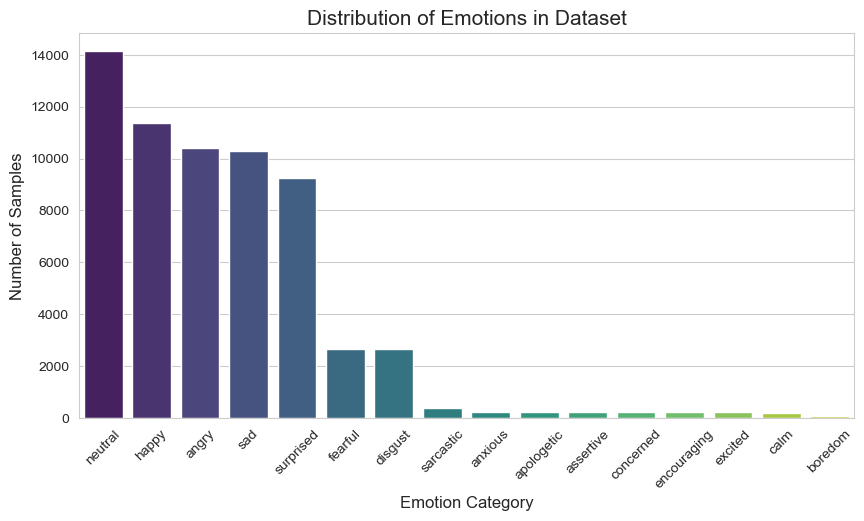

In [26]:
# removing the most unbalanced dataset
Y_all2 = np.concatenate([Y_ravdess, Y_tess, Y_savee, Y_cremad, Y_emodb, Y_esd, Y_hindi, Y_jl, Y_meld], axis=0)
makeThePlot(Y_all2)

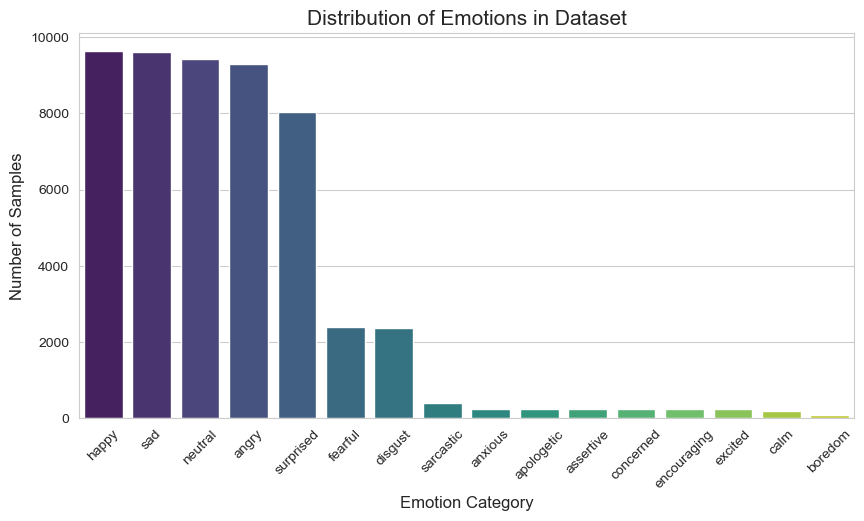

In [27]:
# removing the dataset with utterance of numbers (not a real world scenario)
Y_all3 = np.concatenate([Y_ravdess, Y_tess, Y_savee, Y_cremad, Y_emodb, Y_esd, Y_hindi, Y_jl], axis=0)
makeThePlot(Y_all3)

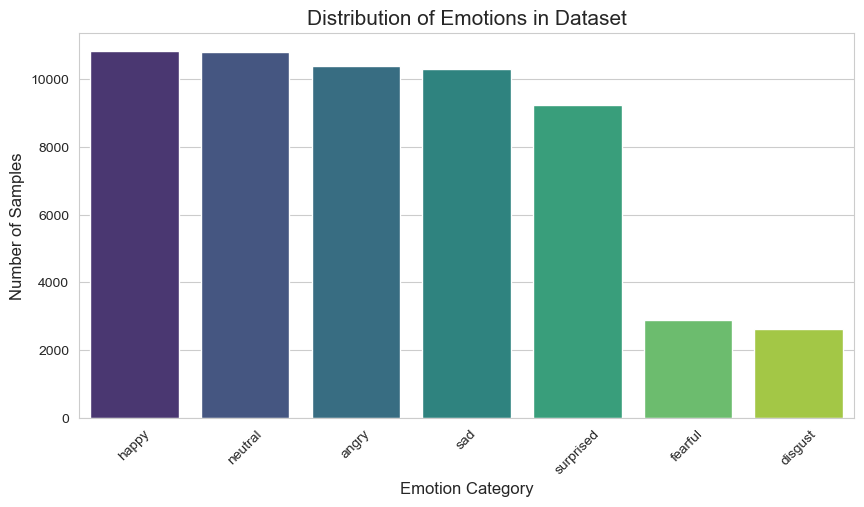

In [34]:
# After balancing the datasets, and dropping the unnecessary emotions. 
# Also not considering the MLEnd dataset (Numerals utterations)

Y_all4 = np.concatenate([Y_ravdess, Y_tess, Y_savee, Y_cremad, Y_emodb, Y_esd, Y_hindi, Y_meld, Y_jl], axis=0)
makeThePlot(Y_all4)